# GAT Basic — Next-Event Prediction on Helpdesk

This notebook demonstrates **next-event prediction** using the basic Dual-GAT architecture
on the [Helpdesk](https://doi.org/10.4121/uuid:0c60edf1-6f83-4e75-9367-4c63b3e9d5bb) event log.

## Model overview

| Component | Description |
|-----------|-------------|
| Architecture | Two parallel GAT paths — one for **learned event embeddings**, one for **encoded features** — fused through a final GAT layer |
| Graph structure | Each case becomes a sequential graph: nodes = events, edges = consecutive transitions, edge attributes = inter-event time differences |
| Task | Predict the **next event** at every position in the sequence |

### Notebook outline
1. Setup & Imports
2. Load & Explore the Dataset
3. Train the Model
4. Evaluate with Comprehensive Metrics
5. Summary & Next Steps

In [1]:
# ── 0. Setup ──────────────────────────────────────────────────────────
# Ensure the library is importable when running from the examples/ folder.
from pathlib import Path
import sys, warnings

root = Path.cwd().resolve()
src = root / "src" if (root / "src").exists() else root.parent / "src"
sys.path.insert(0, str(src))
warnings.filterwarnings("ignore", category=FutureWarning)

## 1. Load & Explore the Dataset

The **Helpdesk** log contains ~4,580 cases and ~21,000 events from a ticketing system.
We rename columns to a standard schema and drop cases shorter than 2 events
(a sequence needs at least one transition to build a graph).

In [2]:
import pandas as pd

data_dir = Path.cwd() / "data" if (Path.cwd() / "data").exists() else Path.cwd() / "examples" / "data"
df = pd.read_csv(data_dir / "Helpdesk.csv")

# Standardise column names
df = df.rename(columns={
    "case:concept:name": "case_id",
    "concept:name":      "event",
    "time:timestamp":    "time",
    "lifecycle:transition": "status",
    "case:variant-index":   "variant_index",
})

df = df.dropna(subset=["case_id", "event", "time"]).copy()
df["time"] = pd.to_datetime(df["time"], utc=True)
df = df[df.groupby("case_id")["case_id"].transform("size") >= 2].reset_index(drop=True)

# Quick overview
n_cases  = df["case_id"].nunique()
n_events = len(df)
n_acts   = df["event"].nunique()
avg_len  = df.groupby("case_id").size().mean()

print(f"Cases: {n_cases}  |  Events: {n_events}  |  Activities: {n_acts}  |  Avg length: {avg_len:.1f}")
df.head()

Cases: 4580  |  Events: 21348  |  Activities: 14  |  Avg length: 4.7


,event,status,org:resource,time,Activity,Resource,case_id,case:variant,variant_index,case:creator
0,Assign seriousness,complete,Value 2,2010-01-13 08:40:25+00:00,Assign seriousness,Value 2,Case3608,Variant 33,33,Fluxicon Disco
1,Take in charge ticket,complete,Value 2,2010-01-29 08:52:27+00:00,Take in charge ticket,Value 2,Case3608,Variant 33,33,Fluxicon Disco
2,Resolve ticket,complete,Value 2,2010-01-29 08:52:34+00:00,Resolve ticket,Value 2,Case3608,Variant 33,33,Fluxicon Disco
3,Closed,complete,Value 5,2010-02-13 08:52:48+00:00,Closed,Value 5,Case3608,Variant 33,33,Fluxicon Disco
4,Closed,complete,Value 5,2010-02-13 08:52:48+00:00,Closed,Value 5,Case3608,Variant 33,33,Fluxicon Disco


## 2. Train the Model

A single call to `gat_basic()` handles the full pipeline:
encoding → graph construction → train/test split → model training.

**Key parameters:**
- `cat_event` — categorical columns encoded as one-hot event-level features
- `num_seq`  — numerical sequence-level features (broadcast to all nodes)
- `num_epochs` — set low here for a quick demo; increase for real experiments

In [9]:
from timegnn import gat_basic

result = gat_basic(
    df,
    case_col="case_id",
    event_col="event",
    time_col="time",
    cat_event=["event"],         # encode activity as one-hot feature
    num_event=[],
    seq_cols=["variant_index"],   # columns to consider for sequence-level features
    cat_seq=[],
    num_seq=["variant_index"],    # numeric sequence-level feature
    num_epochs=3,
    batch_size=16,
)

model = result["model"]
pd.DataFrame(result["history"])

,epoch,train_loss,train_acc,test_loss,test_acc
0,1,0.564606,0.835262,0.625401,0.786747
1,2,0.499416,0.844223,0.677624,0.781187
2,3,0.489580,0.844104,0.589556,0.780743


### Optional: use the full advanced configuration

This example shows all main training controls in one place:
- network depth (`num_layers`)
- regularization (`dropout`, `use_batch_norm`)
- hidden activation (`activation`)
- early stopping (`patience`, `delta`)

In [ ]:
from timegnn import GATBasicConfig, gat_basic

cfg = GATBasicConfig(
    num_layers=3,
    dropout=0.20,
    use_batch_norm=True,
    activation="gelu",
    num_epochs=30,
    patience=5,
    delta=1e-4,
    batch_size=16,
)

result_cfg = gat_basic(
    df,
    case_col="case_id",
    event_col="event",
    time_col="time",
    cat_event=["event"],
    num_event=[],
    seq_cols=["variant_index"],
    cat_seq=[],
    num_seq=["variant_index"],
    config=cfg,
)

model = result_cfg["model"]
pd.DataFrame(result_cfg["history"]).tail()

,epoch,train_loss,train_acc,test_loss,test_acc
0,1,0.629375,0.816865,0.729532,0.624861
1,2,0.526402,0.832235,0.668327,0.777630
2,3,0.522415,0.835143,0.627914,0.790305
3,4,0.493106,0.841315,0.594207,0.783189
4,5,0.469927,0.846359,0.621294,0.784301
5,6,0.463648,0.843036,0.522426,0.792751
6,7,0.460968,0.842917,0.507939,0.788748
7,8,0.446784,0.843629,0.591338,0.790972
8,9,0.447541,0.841671,0.688406,0.694685
9,10,0.449385,0.841434,0.721937,0.769624


## Visualize Model Topology

Use `plot_model_topology` to inspect the trained architecture and parameter distribution.

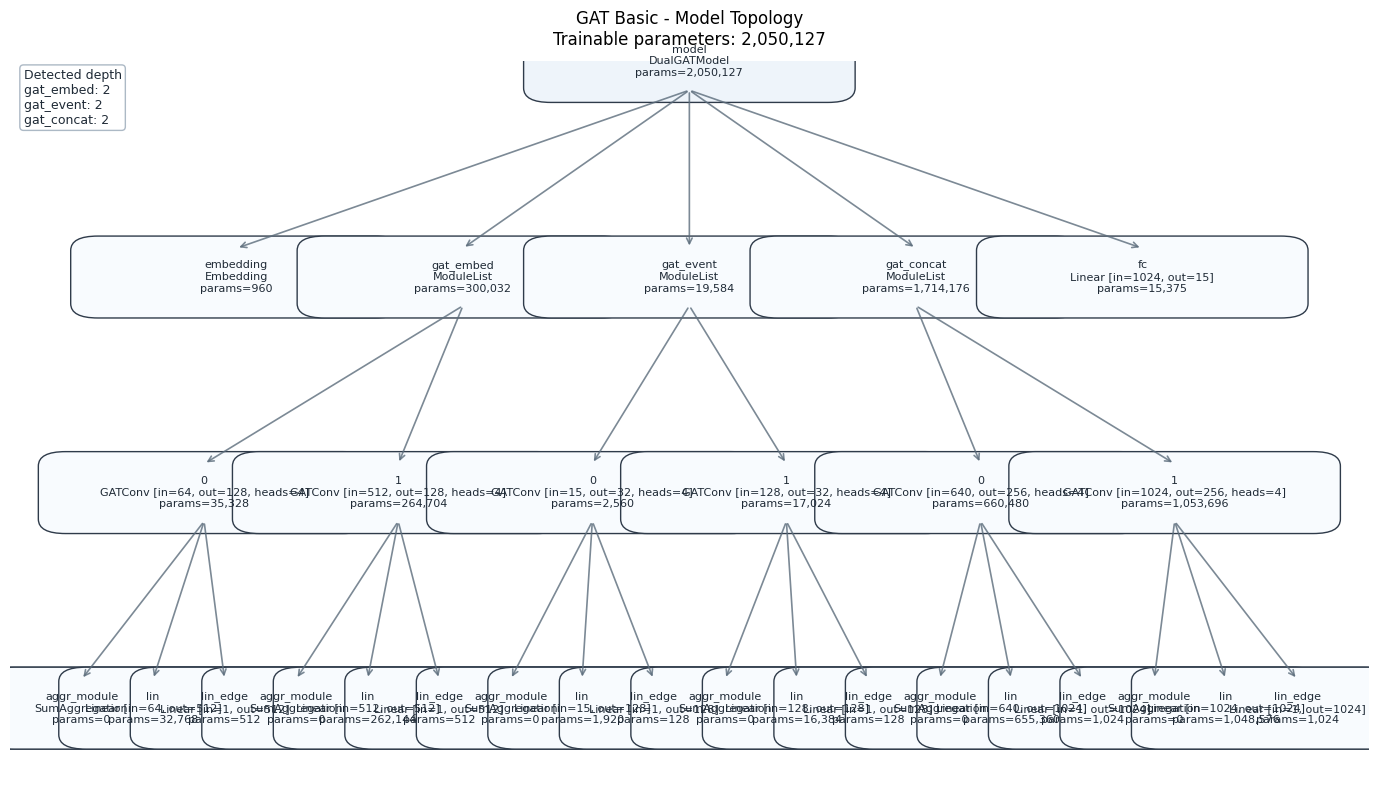

In [6]:
from timegnn import plot_model_topology

fig, ax = plot_model_topology(
    model,
    max_depth=4,
    title="GAT Basic - Model Topology",
)

## 3. Evaluate with Comprehensive Metrics

We re-create the feature transformer to build a DataLoader, then compute:

| Metric | Level | Description |
|--------|-------|-------------|
| **Top-k accuracy** | event | Is the true next event in the top k predictions? |
| **BLEU** | sequence | N-gram overlap between predicted and true sequences |
| **DLS** | sequence | Damerau-Levenshtein similarity (edit-distance based) |
| **Exact match** | sequence | Fraction of perfectly predicted sequences |

> **Note:** metrics are computed on the **full dataset** here for demonstration.
> The recipe already evaluates on a held-out test split during training (see history above).

In [7]:
import torch
from torch.utils.data import DataLoader
from timegnn import (
    EventLogTransformer, top_k_accuracy, predict, predict_per_sequence,
    average_bleu_score, compute_dls_and_exact_match,
    analyze_sequence_errors,
)
from timegnn.data.pyg import CustomDataset, custom_collate_fn

# Build the same transformer used during training
transformer = EventLogTransformer(
    case_col="case_id", event_col="event", time_col="time",
    cat_event=["event"], num_event=[],
    seq_cols=["variant_index"], cat_seq=[], num_seq=["variant_index"],
    mode="gat_basic",
).fit(df)

transformed = transformer.transform(df)
dataset = CustomDataset(transformed.event_features, transformed.labels)
loader  = DataLoader(dataset, batch_size=16, shuffle=False, collate_fn=custom_collate_fn)

device = "cuda" if torch.cuda.is_available() else "cpu"
model  = model.to(device)

# ── Event-level metrics ──
preds_flat, labels_flat, outputs = predict(model, loader, device)
print(f"Top-1 accuracy: {top_k_accuracy(outputs, labels_flat, k=1):.4f}")
print(f"Top-3 accuracy: {top_k_accuracy(outputs, labels_flat, k=3):.4f}")
print(f"Top-5 accuracy: {top_k_accuracy(outputs, labels_flat, k=5):.4f}")

# ── Sequence-level metrics ──
preds_seq, labels_seq = predict_per_sequence(model, loader, device)
bleu = average_bleu_score(preds_seq, labels_seq)
dls, exact = compute_dls_and_exact_match(preds_seq, labels_seq)
print(f"\nBLEU:  {bleu:.4f}")
print(f"DLS:   {dls:.4f}")
print(f"Exact: {exact:.4f}")

# ── Error summary ──
print("\nSequence error summary:")
print(analyze_sequence_errors(model, loader, device))

Top-1 accuracy: 0.8267
Top-3 accuracy: 0.9822
Top-5 accuracy: 0.9970

BLEU:  0.6731
DLS:   0.8490
Exact: 0.5417

Sequence error summary:
(array([ 697, 1487,  675,  352,  217,  125,   62,   36,   23,   12,    6,
          3,    3,    1]), {(14, 12): 79, (14, 8): 59, (12, 0): 442, (10, 14): 902, (12, 10): 566, (10, 1): 219, (10, 12): 289, (12, 2): 16, (12, 1): 209, (14, 2): 34, (14, 10): 294, (1, 10): 123, (12, 14): 248, (14, 11): 3, (12, 8): 42, (4, 1): 24, (10, 8): 17, (1, 12): 54, (10, 2): 16, (0, 14): 4, (12, 7): 2, (10, 5): 2, (4, 13): 2, (10, 4): 6, (0, 12): 3, (12, 4): 9, (12, 9): 10, (8, 9): 2, (4, 12): 2, (4, 10): 10, (1, 14): 4, (1, 8): 1, (10, 0): 1, (10, 9): 1, (10, 11): 1, (12, 11): 1, (14, 13): 1, (4, 3): 1}, {'min': 2, 'max': 15, 'mean': np.float64(4.661135371179039), 'median': np.float64(4.0)})


## 4. Summary & Next Steps

This notebook showed the **simplest GAT variant** (`gat_basic`).
To explore richer architectures try:

| Notebook | What it adds |
|----------|--------------|
| `gat_status_full` | Edge-type embeddings from lifecycle transitions |
| `gat_time_decay_full` | Exponential time-decay attention (α × e^(−λΔt)) |
| `gat_time_decay_status_full` | Both time decay **and** edge-type embeddings |
| `prefix_gcn_full` | Prefix-based GCN for sliding-window classification |
| `gat_outcome_bpi_full` | Case-level outcome prediction |

## Appendix — Ablation Benchmark Template (Depth / BatchNorm / Activation)

This optional cell runs a compact grid-search style benchmark to compare architecture and training options:

- `num_layers`
- `use_batch_norm`
- `activation`
- (fixed) early stopping via `patience` and `delta`

The output table is sorted by best test accuracy and reports early-stop behavior.

In [ ]:
import itertools
import pandas as pd
from timegnn import GATBasicConfig, gat_basic

# Keep this grid small at first; expand once the pipeline is stable.
layer_grid = [1, 2, 3]
bn_grid = [False, True]
activation_grid = ["relu", "gelu", "elu"]

base_kwargs = dict(
    case_col="case_id",
    event_col="event",
    time_col="time",
    cat_event=["event"],
    num_event=[],
    seq_cols=["variant_index"],
    cat_seq=[],
    num_seq=["variant_index"],
)

rows = []
for num_layers, use_batch_norm, activation in itertools.product(layer_grid, bn_grid, activation_grid):
    cfg = GATBasicConfig(
        num_layers=num_layers,
        dropout=0.20,
        use_batch_norm=use_batch_norm,
        activation=activation,
        num_epochs=30,
        patience=5,
        delta=1e-4,
        batch_size=16,
    )

    result_ablation = gat_basic(df, config=cfg, **base_kwargs)
    hist = pd.DataFrame(result_ablation["history"])

    best_idx = hist["test_acc"].idxmax()
    rows.append({
        "num_layers": num_layers,
        "use_batch_norm": use_batch_norm,
        "activation": activation,
        "best_test_acc": float(hist.loc[best_idx, "test_acc"]),
        "best_epoch": int(best_idx) + 1,
        "final_test_acc": float(hist["test_acc"].iloc[-1]),
        "epochs_ran": len(hist),
    })

ablation_df = pd.DataFrame(rows).sort_values(
    by=["best_test_acc", "final_test_acc"],
    ascending=False,
).reset_index(drop=True)

ablation_df